# Rollout Analysis
Plot actual vs target joint positions per joint from a `ur_rtde_real_time.py` NPZ log.

In [134]:
import sys
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

# Put the repo root on sys.path so `from scripts.eval_boxhinge_rollout import ...`
# works regardless of where Jupyter was launched (the notebook's CWD is
# notebooks/, so the repo-root `scripts/` package isn't importable by default).
_repo_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts").is_dir()),
    Path.cwd(),
)
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

joint_names = ["shoulder_pan", "shoulder_lift", "elbow", "wrist_1", "wrist_2", "wrist_3"]

# Trajectory dt — both real-robot (ur_rtde_real_time.py at 500 Hz) and sim (record.py at
# 50 Hz) rollouts share the same underlying policy/trajectory rate of 50 Hz, so this is
# the constant we use to derive decimation = round(POLICY_DT / src_dt).
POLICY_DT = 0.02


def _src_dt(d):
    """Sample period of the rollout. Both record.py and the new ur_rtde_real_time.py
    write `src_dt`. Older real-rollout npz files don't, so fall back to 500 Hz."""
    return float(d["src_dt"]) if "src_dt" in d.files else (1.0 / 500.0)


def _decimation(d):
    """Control steps per policy step. 10 for real (500 Hz / 50 Hz), 1 for sim."""
    return max(1, int(round(POLICY_DT / _src_dt(d))))


def _rate_hz(d):
    """Sample rate of the rollout in Hz, for axis labels."""
    return 1.0 / _src_dt(d)


def _load_rollout(npz_path):
    """Shared loader: returns (npz_path, npz_dict, title, decimation, rate_hz, traj)."""
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    title = npz_path.stem
    decimation = _decimation(d)
    rate_hz = _rate_hz(d)
    run_dir = npz_path.parent.parent
    env_yaml = run_dir / "params" / "env.yaml"
    with open(env_yaml, "r") as f:
        env_cfg = yaml.unsafe_load(f)
    traj_path = env_cfg["trajectory_path"]
    if not Path(traj_path).is_absolute():
        traj_path = run_dir.parent.parent.parent.parent / traj_path  # relative to repo root
    traj = np.load(traj_path)
    return npz_path, d, title, decimation, rate_hz, traj


def analyze_joints(npz_path, ds=5):
    """Plot actual / target / reference joint positions per joint from a rollout npz."""
    _, d, title, decimation, rate_hz, traj = _load_rollout(npz_path)

    actual = d["actual_q"]
    expected = d["expected_q"]
    target = d["target_q"]
    steps = d["steps"]

    joints_target_full = traj["joints_target"] if "joints_target" in traj.files else traj["joints_target_l"]
    joints_full = traj["joints"] if "joints" in traj.files else traj["joints_l"]

    # Mirror the control thread's interpolation: starts from the planned initial joint
    # position (joints[0]), then transitions to joints_target[0] over the first
    # `decimation` steps, and so on. Prepending joints[0] makes step (i+1)*decimation
    # land exactly on trajectory waypoint i.
    ref_points = np.vstack([joints_full[0:1], joints_target_full])  # (T+1, 6)
    traj_x = np.arange(len(ref_points)) * decimation  # 0, decimation, 2*decimation, ...
    ref_steps = np.arange(traj_x[-1] + 1)
    ref_target = np.empty((len(ref_steps), ref_points.shape[1]))
    for j in range(ref_points.shape[1]):
        ref_target[:, j] = np.interp(ref_steps, traj_x, ref_points[:, j])

    print(f"{title}: {len(steps)} rollout steps, {len(ref_steps)} ref steps, "
          f"rate={rate_hz:.0f}Hz, decimation={decimation}, "
          f"gain={float(d['gain'])}, lookahead={float(d['lookahead_time'])}, "
          f"action_scale={float(d['action_scale'])}")

    xlabel = f"step ({rate_hz:.0f}Hz)"

    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(steps[::ds], expected[::ds, i], label='reference q', color='gray', linestyle='--', alpha=0.7)
        ax.plot(ref_steps[::ds], ref_target[::ds, i], label='reference target', color='tab:green', linestyle=':', alpha=0.8)
        ax.plot(steps[::ds], target[::ds, i], label='policy target', color='tab:orange', alpha=0.8)
        ax.plot(steps[::ds], actual[::ds, i], label='actual', color='tab:blue', alpha=0.8)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()


def analyze_box_pose(npz_path, ds=5):
    """Plot box pose estimate (from pose listener) vs ground truth (reference trajectory
    sampled at the logged phase)."""
    _, d, title, _, rate_hz, traj = _load_rollout(npz_path)
    steps = d["steps"]
    xlabel = f"step ({rate_hz:.0f}Hz)"

    if "actual_obj_pos" not in d.files or "actual_obj_quat" not in d.files or "phase" not in d.files:
        print("(box pose / phase missing from npz; skipping box-pose plot)")
        return
    
    obj_poses_full = traj["obj_poses"]  # (T, 7): pos[:3], quat[3:]
    actual_obj_pos = d["actual_obj_pos"]    # (N, 3) — NaN where no pose was available
    actual_obj_quat = d["actual_obj_quat"]  # (N, 4) — NaN where no pose was available
    phase = d["phase"]                     # (N,) float trajectory-index units

    # Reference object pose at each rollout step's logged phase. np.interp clamps to the
    # endpoints, so phases outside [0, T-1] just stick to the closest end.
    T_obj = obj_poses_full.shape[0]
    obj_idx = np.arange(T_obj)
    ref_obj_pos = np.column_stack([
        np.interp(phase, obj_idx, obj_poses_full[:, j]) for j in range(3)
    ])
    ref_obj_quat = np.column_stack([
        np.interp(phase, obj_idx, obj_poses_full[:, 3 + j]) for j in range(4)
    ])

    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    pos_slots = [(0, 0), (0, 1), (1, 0)]
    pos_labels = ["pos x", "pos y", "pos z"]
    for i, ((r, c), label) in enumerate(zip(pos_slots, pos_labels)):
        ax = axes[r, c]
        ax.plot(steps[::ds], ref_obj_pos[::ds, i], label='ground truth (trajectory)',
                color='tab:green', linestyle='--', alpha=0.85)
        ax.plot(steps[::ds], actual_obj_pos[::ds, i], label='estimate (pose listener)',
                color='tab:blue', alpha=0.85)
        ax.set_title(label, fontsize=10)
        ax.set_ylabel('m')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[1, 1].axis('off')

    quat_slots = [(2, 0), (2, 1), (3, 0), (3, 1)]
    quat_labels = ["quat[0]", "quat[1]", "quat[2]", "quat[3]"]
    for i, ((r, c), label) in enumerate(zip(quat_slots, quat_labels)):
        ax = axes[r, c]
        ax.plot(steps[::ds], ref_obj_quat[::ds, i], label='ground truth (trajectory)',
                color='tab:green', linestyle='--', alpha=0.85)
        ax.plot(steps[::ds], actual_obj_quat[::ds, i], label='estimate (pose listener)',
                color='tab:blue', alpha=0.85)
        ax.set_title(label, fontsize=10)
        ax.set_ylabel('quat component')
        ax.grid(True, alpha=0.3)
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(f"Box estimate vs ground truth — {title}", fontsize=11)
    plt.tight_layout()


def analyze(npz_path, ds=5):
    """Wrapper: plot joints then box pose (preserves the old single-call entry point)."""
    analyze_joints(npz_path, ds=ds)
    analyze_box_pose(npz_path, ds=ds)


In [135]:
def compare_rollouts(npz_path_a, npz_path_b, ds=1, plot_target=True, plot_expected=True):
    """Overlay target and actual joint positions from two rollouts per joint."""
    npz_path_a = Path(npz_path_a)
    npz_path_b = Path(npz_path_b)
    a = np.load(npz_path_a)
    b = np.load(npz_path_b)

    print(a.keys())
    label_a = npz_path_a.stem
    label_b = npz_path_b.stem

    # Use rollout A's rate for the axis label; if the two rollouts are at different
    # rates the comparison is still meaningful per-step but the label can't reflect both.
    xlabel = f"step ({_rate_hz(a):.0f}Hz)"

    # --- Position overlay ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(a["steps"][0:100:ds], a["actual_q"][0:100:ds, i], color='tab:orange',
                alpha=0.9, label=f'{label_a} actual')
        ax.plot(b["steps"][0:100:ds], b["actual_q"][0:100:ds, i], color='tab:blue',
                alpha=0.9, label=f'{label_b} actual')
        
        if plot_target:
            ax.plot(a["steps"][0:100:ds], a["target_q"][0:100:ds, i], color='tab:orange', linestyle='--',
                alpha=0.7, label=f'{label_a} target')
            ax.plot(b["steps"][0:100:ds], b["target_q"][0:100:ds, i], color='tab:blue', linestyle='--',
                alpha=0.7, label=f'{label_b} target')
            
        if plot_expected:
            ax.plot(a["steps"][0:100:ds], a["expected_q"][0:100:ds, i], color='tab:orange', linestyle='dotted',
                alpha=0.7, label=f'{label_a} target')
            ax.plot(b["steps"][0:100:ds], b["expected_q"][0:100:ds, i], color='tab:blue', linestyle='dotted',
                alpha=0.7, label=f'{label_b} target')
            
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(f"Rollout comparison: {label_a}  vs  {label_b}", fontsize=11)
    plt.tight_layout()

    # --- Tracking error overlay (actual - target) ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(a["steps"][::ds], (a["actual_q"] - a["target_q"])[::ds, i],
                color='tab:orange', alpha=0.85, label=label_a)
        ax.plot(b["steps"][::ds], (b["actual_q"] - b["target_q"])[::ds, i],
                color='tab:blue', alpha=0.85, label=label_b)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('actual - target (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle("Tracking error comparison", fontsize=11)
    plt.tight_layout()

In [136]:
def compare_upsampling_rollout(npz_path, alpha=0.05, policy_decimation=None, ds=5, start_i=0, end_i=None):
    """Given a real rollout's upsampled target_q (produced by linear interpolation at run
    time), extract the underlying 50 Hz policy waypoints and show what the upsampled
    command would have looked like if the control thread had used an IIR low-pass instead.

    Waypoints are recovered by decimating target_q every `policy_decimation` steps. When
    `policy_decimation=None` we read `src_dt` from the npz to derive it (10 for real-robot
    rollouts at 500 Hz, 1 for sim rollouts at 50 Hz). On a sim rollout decimation=1 means
    every step is already a waypoint, so the linear/IIR upsampling is a no-op.
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    target = d["target_q"]  # (N, 6) at the rollout's source rate
    steps = d["steps"]
    rate_hz = _rate_hz(d)

    if policy_decimation is None:
        policy_decimation = _decimation(d)

    # Recover 50 Hz waypoints from the logged ramps.
    wp_idx = np.arange(0, len(target), policy_decimation)
    waypoints = target[wp_idx]  # (T, 6)

    wp_steps = steps[wp_idx]

    if end_i is None:
        end_i = len(target)


    waypoints = waypoints[start_i:end_i]
    wp_steps = wp_steps[start_i:end_i]

    # Re-upsample to the source rate.
    T = len(waypoints)
    segment_steps = policy_decimation
    total_steps = (T - 1) * segment_steps + 1
    dense_x = np.arange(total_steps)
    wp_x = np.arange(T) * segment_steps

    # Linear interpolation (per joint)
    linear = np.empty((total_steps, 6))
    for j in range(6):
        linear[:, j] = np.interp(dense_x, wp_x, waypoints[:, j])

    # First-order IIR low-pass on ZOH-upsampled command
    iir = np.empty_like(linear)
    iir[0] = waypoints[0]
    one_minus_alpha = 1.0 - alpha
    for i, wp in enumerate(waypoints[:-1]):
        for k in range(segment_steps):
            n = i * segment_steps + k
            iir[n + 1] = one_minus_alpha * iir[n] + alpha * wp

    # Align x-axis with the original rollout step indices
    dense_abs_steps = wp_steps[0] + dense_x

    xlabel = f"step ({rate_hz:.0f}Hz)"

    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(wp_steps, waypoints[:, i], 'o', markersize=2.5, color='k',
                alpha=0.5, label='policy waypoints (50 Hz)')
        ax.plot(dense_abs_steps[::ds], linear[::ds, i], label='linear interp (actual)',
                color='tab:green', alpha=0.85)
        ax.plot(dense_abs_steps[::ds], iir[::ds, i], label=f'IIR (α={alpha})',
                color='tab:red', alpha=0.85)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel(xlabel)
    axes[-1, 1].set_xlabel(xlabel)
    fig.suptitle(f"Rollout targets: linear (actual) vs IIR reconstruction — {npz_path.stem}", fontsize=11)
    plt.tight_layout()

In [137]:
def analyze_phase(npz_path, policy_decimation=None, ds=1, smooth=10):
    """Plot phase trajectory and dphase (per-policy-step phase advance) from a rollout npz.

    `phase` is logged at the rollout's source rate, but only updates when the policy thread
    sets a new value (every `policy_decimation` control steps), so the raw per-step diff is
    dominated by the control thread's linear-blend ramp between policy waypoints. We
    decimate phase to the policy rate and diff there. Even at policy rate, `dphase` can
    briefly read above 1.0 due to async timing between the control and policy threads.
    The `smooth` window averages it out.

    When `policy_decimation=None` we read `src_dt` from the npz to derive it (10 for real
    at 500 Hz, 1 for sim at 50 Hz). With decimation=1 the raw and policy-rate phase are
    the same, so this just plots phase and its first difference.

    Args:
        npz_path: path to a rollout npz from ur_rtde_real_time.py or record.py
        policy_decimation: control-steps per policy step. None ⇒ derive from src_dt.
        ds: visual downsample for the phase line plot only
        smooth: moving-average window (in policy steps) applied to dphase. 0 = no smoothing.
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    if "phase" not in d.files:
        print("(phase not in npz; nothing to plot)")
        return
    phase = d["phase"]
    steps = d["steps"]
    title = npz_path.stem
    rate_hz = _rate_hz(d)

    if policy_decimation is None:
        policy_decimation = _decimation(d)

    # Per-policy-step phase delta
    policy_phase = phase[::policy_decimation]
    policy_steps = steps[::policy_decimation]
    dphase_raw = np.diff(policy_phase)
    dphase_steps = policy_steps[:-1]

    # Boxcar smoothing on dphase
    if smooth and smooth > 1 and len(dphase_raw) >= smooth:
        kernel = np.ones(smooth) / smooth
        dphase_smooth = np.convolve(dphase_raw, kernel, mode="same")
    else:
        dphase_smooth = dphase_raw

    print(f"{title}: {len(steps)} ctrl steps, {len(policy_phase)} policy steps, "
          f"phase ∈ [{phase.min():.2f}, {phase.max():.2f}], "
          f"dphase mean={dphase_raw.mean():.3f}, frac<1={(dphase_raw < 0.99).mean():.2f}, "
          f"frac<0.2={(dphase_raw < 0.2).mean():.2f}")

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    axes[0].plot(steps[::ds], phase[::ds], color="tab:blue", lw=1)
    axes[0].set_ylabel("phase (trajectory-step units)")
    axes[0].set_title(f"phase — {title}", fontsize=10)
    axes[0].grid(True, alpha=0.3)

    if smooth and smooth > 1 and len(dphase_raw) >= smooth:
        axes[1].plot(dphase_steps, dphase_smooth, color="tab:orange", lw=1.4,
                     label=f"smoothed (w={smooth})")
    else:
        axes[1].plot(dphase_steps, dphase_raw, color="tab:orange", lw=1, label="dphase")
    axes[1].axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="nominal (=1)")
    axes[1].axhline(0.0, color="red", linestyle="--", alpha=0.5, label="full pause (=0)")
    axes[1].set_ylabel("dphase per policy step")
    axes[1].set_xlabel(f"step ({rate_hz:.0f}Hz)")
    axes[1].set_title("dphase (= phase advance per policy step)", fontsize=10)
    axes[1].legend(fontsize=8, loc="best")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()


In [138]:
def analyze_box(npz_path, n_arrows=20, arrow_scale=None, ds=1, margin=0.05):
    """Top-down xy view of the box pose: position trace + yaw arrow at sampled timesteps,
    actual (from pose listener) vs reference (from trajectory file).
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    needed = ["actual_obj_pos", "actual_obj_quat", "phase"]
    missing = [k for k in needed if k not in d.files]
    if missing:
        print(f"(missing {missing} in npz; cannot plot)")
        return
    actual_pos = d["actual_obj_pos"]
    actual_quat = d["actual_obj_quat"]
    phase = d["phase"]
    title = npz_path.stem

    run_dir = npz_path.parent.parent
    env_yaml = run_dir / "params" / "env.yaml"
    with open(env_yaml, "r") as f:
        env_cfg = yaml.unsafe_load(f)
    traj_path = env_cfg["trajectory_path"]
    if not Path(traj_path).is_absolute():
        traj_path = run_dir.parent.parent.parent.parent / traj_path
    traj = np.load(traj_path)
    obj_poses_full = traj["obj_poses"]

    T_obj = obj_poses_full.shape[0]
    obj_idx = np.arange(T_obj)
    ref_pos = np.column_stack([np.interp(phase, obj_idx, obj_poses_full[:, j]) for j in range(3)])
    ref_quat = np.column_stack([np.interp(phase, obj_idx, obj_poses_full[:, 3 + j]) for j in range(4)])

    def yaw_from_quat(q):
        w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
        return np.arctan2(2 * (w * z + x * y), 1 - 2 * (y * y + z * z))
    actual_yaw = yaw_from_quat(actual_quat)
    ref_yaw = yaw_from_quat(ref_quat)

    if arrow_scale is None:
        if "object_dims" in traj.files:
            box_dims = traj["object_dims"]
        else:
            try:
                box_dims = env_cfg["cube_cfg"]["spawn"]["size"]
            except Exception:
                box_dims = (0.235, 0.34, 0.27)
        arrow_scale = max(box_dims[0], box_dims[1]) / 2.0

    valid = ~np.isnan(actual_pos[:, 0])

    fig, ax = plt.subplots(figsize=(9, 9))

    ax.plot(ref_pos[::ds, 0], ref_pos[::ds, 1], color="tab:green", lw=1.5,
            alpha=0.85, label="reference")
    if valid.any():
        av = actual_pos[valid]
        ax.plot(av[::ds, 0], av[::ds, 1], color="tab:blue", lw=1.5,
                alpha=0.85, label="actual")

    N = len(phase)
    sample_idx = np.linspace(0, N - 1, max(2, n_arrows)).astype(int)

    rx = ref_pos[sample_idx, 0]
    ry = ref_pos[sample_idx, 1]
    ru = np.cos(ref_yaw[sample_idx]) * arrow_scale
    rv = np.sin(ref_yaw[sample_idx]) * arrow_scale
    ax.quiver(rx, ry, ru, rv, color="tab:green", angles="xy", scale_units="xy",
              scale=1, width=0.004, alpha=0.6)

    a_valid_mask = ~np.isnan(actual_pos[sample_idx, 0])
    a_x_tips, a_y_tips = np.array([]), np.array([])
    if a_valid_mask.any():
        a_idx = sample_idx[a_valid_mask]
        ax_x = actual_pos[a_idx, 0]
        ax_y = actual_pos[a_idx, 1]
        au = np.cos(actual_yaw[a_idx]) * arrow_scale
        av_ = np.sin(actual_yaw[a_idx]) * arrow_scale
        ax.quiver(ax_x, ax_y, au, av_, color="tab:blue", angles="xy", scale_units="xy",
                  scale=1, width=0.004, alpha=0.6)
        a_x_tips = ax_x + au
        a_y_tips = ax_y + av_

    ax.scatter([ref_pos[0, 0]], [ref_pos[0, 1]], c="tab:green", s=70,
               marker="o", edgecolor="k", zorder=5, label="ref start")
    ax.scatter([ref_pos[-1, 0]], [ref_pos[-1, 1]], c="tab:green", s=70,
               marker="X", edgecolor="k", zorder=5, label="ref end")
    if valid.any():
        ax.scatter([av[0, 0]], [av[0, 1]], c="tab:blue", s=70,
                   marker="o", edgecolor="k", zorder=5, label="actual start")
        ax.scatter([av[-1, 0]], [av[-1, 1]], c="tab:blue", s=70,
                   marker="X", edgecolor="k", zorder=5, label="actual end")

    # Compute axis limits that contain all points (path + arrow tails) AND arrow tips.
    # Stack: ref path, arrow origins+tips for both, actual path (only valid rows).
    xs = [ref_pos[:, 0], rx + ru, rx]
    ys = [ref_pos[:, 1], ry + rv, ry]
    if valid.any():
        xs.append(actual_pos[valid, 0])
        ys.append(actual_pos[valid, 1])
    if a_x_tips.size:
        xs.append(a_x_tips)
        ys.append(a_y_tips)
    all_x = np.concatenate(xs)
    all_y = np.concatenate(ys)
    x_min, x_max = float(all_x.min()), float(all_x.max())
    y_min, y_max = float(all_y.min()), float(all_y.max())
    span = max(x_max - x_min, y_max - y_min, 1e-3)
    pad = span * margin
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Top-down box trajectory /u2014 {title}", fontsize=11)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()


In [139]:
def _first_onset(sig, thresh, min_sustained=1):
    """Index of the first sample where `sig` crosses `thresh` and (optionally) stays
    above it for `min_sustained` consecutive samples. Returns None if never crossed.
    min_sustained guards against single-sample noise spikes — useful for the pose
    estimate, which is noisier than the force reading."""
    above = sig >= thresh
    if min_sustained <= 1:
        idx = np.argmax(above)
        return int(idx) if above[idx] else None
    # Sliding window: first i where above[i:i+min_sustained] is all True.
    kernel = np.ones(min_sustained, dtype=int)
    run = np.convolve(above.astype(int), kernel, mode="valid")
    hit = np.argmax(run == min_sustained)
    return int(hit) if run[hit] == min_sustained else None


def _first_peak_over(sig, thresh, win=1):
    """Index of the first LOCAL MAXIMUM of `sig` whose value is >= `thresh`. Sample i
    counts as a peak if it equals the max of sig[i-win : i+win+1], so win>=1 suppresses
    single-sample noise spikes. Returns None if no qualifying peak.

    Use this (instead of _first_onset) to mark the breakaway instant: in stick-slip
    contact the force rises, peaks as static friction is overcome, then drops to the
    kinetic level — so the first peak above threshold is a better proxy for "the box
    actually starts moving" than the first threshold crossing (which fires early, while
    force is still ramping)."""
    n = len(sig)
    for i in np.where(sig >= thresh)[0]:
        lo = max(0, i - win)
        hi = min(n, i + win + 1)
        if sig[i] >= sig[lo:hi].max():
            return int(i)
    return None


def compare_force_to_box_motion(npz_path, reference="initial", ds=1, force="linear",
                                 force_marker="threshold", force_onset_thresh=None,
                                 pos_onset_thresh=0.005, rot_onset_thresh=None,
                                 baseline_window=40, min_sustained_s=0.0,
                                 peak_win_s=0.02, mark_onsets=True, hover=False):
    """Compare TCP force to box motion, and detect/annotate the onset times of each so
    you can read off the force→motion lag directly.

    All three series share one time axis with three y-axes via twinx (force in N on the
    left, |Δpos| in m on the first right spine, |Δrot| in deg on the second right spine).

    Onset detection (on the full-resolution signal, not the ds-downsampled plot):
      - Force: ``|F| - baseline`` where baseline = median of the first
        ``baseline_window`` samples (robot moving to start but box not yet pushed).
        ``force_marker`` selects WHICH instant:
          * "threshold" (default) — first sample exceeding ``force_onset_thresh``.
          * "peak" — first local max above ``force_onset_thresh`` (≈ breakaway; the
            force peaks then drops as static→kinetic friction gives way, so this is a
            better "box starts moving" proxy than the early threshold crossing).
            ``peak_win_s`` sets the ± neighbourhood (s) for the local-max test.
        If ``force_onset_thresh`` is None it auto-picks ``max(3 N, 5·std(baseline))``.
      - Position: first sample where ``|Δpos|`` exceeds ``pos_onset_thresh`` (m, 5 mm).
      - Rotation: only drawn if ``rot_onset_thresh`` (degrees) is given.
    ``min_sustained_s`` (seconds) optionally requires the signal to stay above
    threshold that long before counting (applies to the "threshold" force mode and to
    pos/rot) — set it to e.g. 0.02 to reject pose-estimate noise spikes.

    Args:
        reference: "initial" (default) ⇒ |Δpos|/|Δrot| are cumulative since the first
            valid pose (best for "did the box ultimately move"). "previous" ⇒ per-policy
            -step delta, velocity-like (best for instantaneous force/motion correlation).
        force: "linear" ⇒ ||[Fx,Fy,Fz]||; "full" ⇒ 6D wrench norm.
        hover: if True, attach mplcursors hover annotations (requires an interactive
            backend like ``%matplotlib widget``; no-ops with a hint under inline).
    """
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    needed = ["tcp_force", "actual_obj_pos", "actual_obj_quat", "steps"]
    missing = [k for k in needed if k not in d.files]
    if missing:
        print(f"(missing {missing} in npz; cannot plot)")
        return

    tcp_force = d["tcp_force"]       # (N, 6): Fx, Fy, Fz, Tx, Ty, Tz in UR base frame
    obj_pos = d["actual_obj_pos"]    # (N, 3) — NaN where no pose was available
    obj_quat = d["actual_obj_quat"]  # (N, 4) wxyz
    steps = d["steps"]
    src_dt = _src_dt(d)
    rate_hz = _rate_hz(d)
    title = npz_path.stem
    # Step → seconds (steps may not start at 0 if the rollout was trimmed).
    t = (steps - steps[0]) * src_dt
    min_sustained = max(1, int(round(min_sustained_s / src_dt)))
    peak_win = max(1, int(round(peak_win_s / src_dt)))

    if force == "linear":
        f_mag = np.linalg.norm(tcp_force[:, :3], axis=1)
        f_label = "|F_xyz| (N)"
    elif force == "full":
        f_mag = np.linalg.norm(tcp_force, axis=1)
        f_label = "|wrench| (N / N·m mixed)"
    else:
        raise ValueError(f"force must be 'linear' or 'full', got {force!r}")

    valid = ~np.isnan(obj_pos[:, 0])
    if not valid.any():
        print("(no valid box pose samples; cannot compute motion)")
        return

    if reference == "initial":
        i0 = int(np.argmax(valid))  # first True index
        ref_pos = obj_pos[i0]
        ref_quat = obj_quat[i0]
        pos_diff = np.linalg.norm(obj_pos - ref_pos, axis=1)
        dot = np.clip(np.abs(np.sum(obj_quat * ref_quat, axis=1)), 0.0, 1.0)
        quat_angle = 2.0 * np.arccos(dot)  # rad
        motion_suffix = "vs initial"
    elif reference == "previous":
        decim = _decimation(d)
        pol_pos = obj_pos[::decim]
        pol_quat = obj_quat[::decim]
        pol_pos_diff = np.zeros(len(pol_pos))
        pol_pos_diff[1:] = np.linalg.norm(np.diff(pol_pos, axis=0), axis=1)
        pol_dot = np.clip(np.abs(np.sum(pol_quat[:-1] * pol_quat[1:], axis=1)), 0.0, 1.0)
        pol_quat_angle = np.zeros(len(pol_quat))
        pol_quat_angle[1:] = 2.0 * np.arccos(pol_dot)
        idx = np.minimum(np.arange(len(steps)) // decim, len(pol_pos_diff) - 1)
        pos_diff = pol_pos_diff[idx]
        quat_angle = pol_quat_angle[idx]
        motion_suffix = f"vs prev policy step ({1.0 / (decim * src_dt):.0f}Hz)"
    else:
        raise ValueError(f"reference must be 'initial' or 'previous', got {reference!r}")

    rot_deg = np.degrees(quat_angle)

    # --- Onset detection (on full-resolution signals) ---
    f_baseline = float(np.nanmedian(f_mag[:baseline_window]))
    f_baseline_std = float(np.nanstd(f_mag[:baseline_window]))
    if force_onset_thresh is None:
        force_onset_thresh = max(3.0, 5.0 * f_baseline_std)
    f_delta = f_mag - f_baseline
    if force_marker == "threshold":
        i_force = _first_onset(f_delta, force_onset_thresh, min_sustained)
    elif force_marker == "peak":
        i_force = _first_peak_over(f_delta, force_onset_thresh, peak_win)
    else:
        raise ValueError(f"force_marker must be 'threshold' or 'peak', got {force_marker!r}")
    i_pos = _first_onset(pos_diff, pos_onset_thresh, min_sustained)
    i_rot = (_first_onset(rot_deg, rot_onset_thresh, min_sustained)
             if rot_onset_thresh is not None else None)

    def _fmt(i):
        return "never" if i is None else f"step {int(steps[i])} (t={t[i]:.3f}s)"

    print(f"{title}")
    print(f"  force [{force_marker}] baseline={f_baseline:.2f} N (std={f_baseline_std:.2f}), "
          f"thresh=+{force_onset_thresh:.2f} N → {_fmt(i_force)}")
    print(f"  pos onset thresh={pos_onset_thresh*1000:.1f} mm → {_fmt(i_pos)}")
    if rot_onset_thresh is not None:
        print(f"  rot onset thresh={rot_onset_thresh:.2f} deg → {_fmt(i_rot)}")
    if i_force is not None and i_pos is not None:
        lag = t[i_pos] - t[i_force]
        print(f"  force → box-motion lag = {lag*1000:+.1f} ms "
              f"({'box moves after force' if lag >= 0 else 'box moves BEFORE force (check thresholds)'})")

    # --- Plot: one time axis, three y-axes ---
    fig, ax_f = plt.subplots(figsize=(13, 6))
    ax_p = ax_f.twinx()
    ax_r = ax_f.twinx()
    ax_r.spines["right"].set_position(("axes", 1.08))

    line_f, = ax_f.plot(t[::ds], f_mag[::ds], color="tab:red", lw=1, label=f_label)
    line_p, = ax_p.plot(t[::ds], pos_diff[::ds], color="tab:blue", lw=1,
                        label=f"|Δpos| (m) {motion_suffix}")
    line_r, = ax_r.plot(t[::ds], rot_deg[::ds], color="tab:green", lw=1,
                        label=f"|Δrot| (deg) {motion_suffix}")

    handles = [line_f, line_p, line_r]
    if mark_onsets:
        # Stagger the labels vertically and put a translucent white box behind each
        # so the time stays readable even when the line sits on top of a busy curve.
        for idx, color, yfrac in ((i_force, "tab:red", 0.97),
                                  (i_pos, "tab:blue", 0.80),
                                  (i_rot, "tab:green", 0.63)):
            if idx is None:
                continue
            ax_f.axvline(t[idx], color=color, ls="--", lw=1.2, alpha=0.8)
            ax_f.annotate(
                f"{t[idx]:.3f}s",
                xy=(t[idx], yfrac), xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=color, fontsize=12, ha="left", va="top", rotation=90,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
            )

    ax_f.set_xlabel("time (s)")
    ax_f.set_ylabel(f_label, color="tab:red")
    ax_p.set_ylabel(f"|Δpos| (m) {motion_suffix}", color="tab:blue")
    ax_r.set_ylabel(f"|Δrot| (deg) {motion_suffix}", color="tab:green")
    ax_f.tick_params(axis="y", labelcolor="tab:red")
    ax_p.tick_params(axis="y", labelcolor="tab:blue")
    ax_r.tick_params(axis="y", labelcolor="tab:green")
    ax_f.grid(True, alpha=0.3)
    ax_f.set_title(f"TCP force vs box motion ({reference}, force={force_marker}) — {title}",
                   fontsize=11)
    ax_f.legend(handles=handles, loc="best", fontsize=8)

    if hover:
        try:
            import mplcursors
            cursor = mplcursors.cursor(handles, hover=True)

            @cursor.connect("add")
            def _(sel):
                x, y = sel.target
                sel.annotation.set_text(f"t={x:.3f}s/ny={y:.4g}")
                sel.annotation.get_bbox_patch().set(alpha=0.85)
        except ImportError:
            print("(hover requested but mplcursors not installed: `pip install mplcursors`, "
                  "and use an interactive backend e.g. `%matplotlib widget`)")
        except Exception as e:
            print(f"(hover unavailable under the current backend — switch to "
                  f"`%matplotlib widget`/`notebook`. {type(e).__name__}: {e})")

    plt.tight_layout()


2026-05-19_11-54-01_gain400.0_la0.15_real: 4731 rollout steps, 11811 ref steps, rate=500Hz, decimation=10, gain=400.0, lookahead=0.15, action_scale=0.05


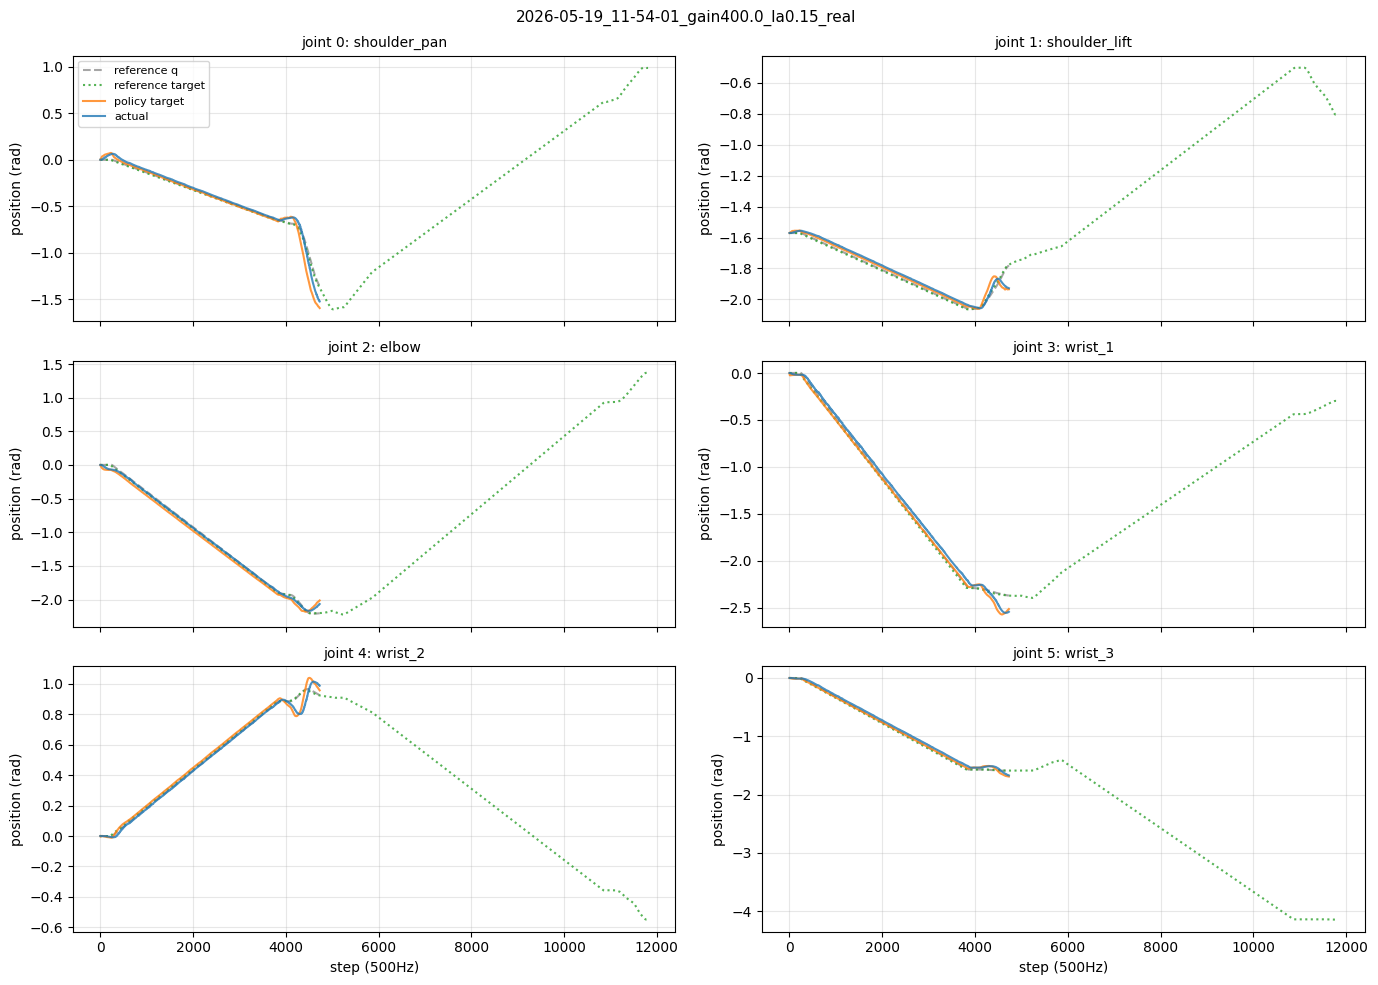

In [141]:
analyze_joints("../logs/rsl_rl/boxhinge/2026-05-17_17-22-43_boxrotate_on_boxhinge/ur_rtde_logs/2026-05-19_11-54-01_gain400.0_la0.15_real.npz")


2026-05-15_14-12-15_gain200.0_la0.15_real_useref
  force [peak] baseline=3.55 N (std=0.30), thresh=+5.00 N → step 3019 (t=6.038s)
  pos onset thresh=100000000000.0 mm → never
  rot onset thresh=1.00 deg → step 3071 (t=6.142s)


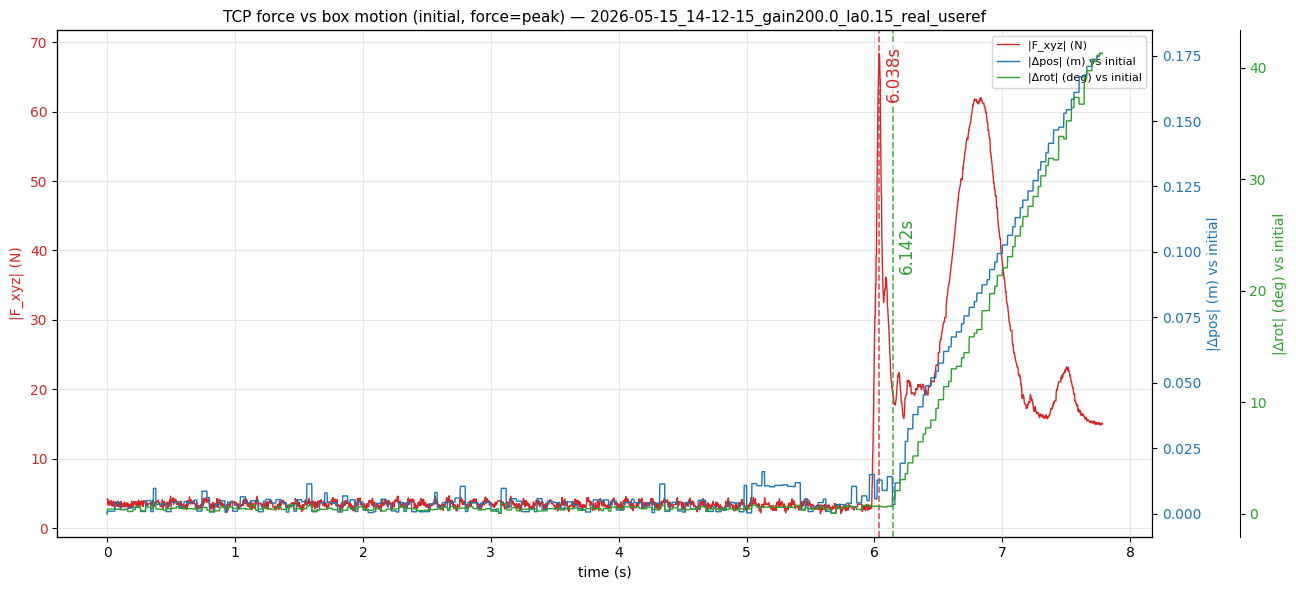

In [142]:
compare_force_to_box_motion(
    "../logs/rsl_rl/boxhinge/2026-05-14_17-00-16_more_regularization/ur_rtde_logs/2026-05-15_14-12-15_gain200.0_la0.15_real_useref.npz ",
    force_marker="peak",
    force_onset_thresh=5,
    pos_onset_thresh=1e8,
    rot_onset_thresh=1,
    peak_win_s=0.4
)

In [196]:
from scripts.eval_boxhinge_rollout import analyze as eval_final_pose, print_summary
import pandas as pd

results = eval_final_pose("../logs/rsl_rl/boxhinge/2026-05-15_18-02-02_gain_changes", False)
df = pd.DataFrame(results)


df = df[df["final_phase"] > 200]
# df = df[df["lookahead"] == 0.15]

len(df)

34

In [197]:
from matplotlib.patches import Patch


def plot_error(results, key="ori_err_deg", sort=True):
    """Bar chart of per-rollout orientation (quaternion) error from
    eval_final_pose(...). One horizontal bar per rollout, coloured by who was
    driving the arm:
        green = policy    (use_ref == False)
        red   = reference (use_ref == True, i.e. a --use_ref nominal replay)

    `results` may be the list of dicts eval_final_pose returns OR a pandas
    DataFrame built from it, so you can pre-filter first
    (e.g. plot_quat_error(df[df.final_phase > 250])).

    key: which orientation-error field to plot —
        "ori_err_deg"          vs reference GOAL, end of trajectory   [default]
        "ori_err_at_phase_deg" vs reference at the final phase reached (tracking)
        "init_ori_err_deg"     box placement / reset offset at the start
    sort: order bars best->worst by `key` (else keep input order).
    """
    rows = results.to_dict("records") if hasattr(results, "to_dict") else list(results)
    if not rows:
        print("(no rollouts to plot)")
        return
    if sort:
        rows = sorted(rows, key=lambda r: r[key])

    labels = [str(r["npz"]).removesuffix(".npz") for r in rows]
    vals = [r[key] for r in rows]
    colors = ["tab:red" if r["use_ref"] else "tab:green" for r in rows]

    fig, ax = plt.subplots(figsize=(12, max(3, 0.42 * len(rows))))
    y = np.arange(len(rows))
    bars = ax.barh(y, vals, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()  # smallest error on top when sorted
    ax.set_xlabel(f"{key}  (deg)")
    ax.set_title(f"Orientation error per rollout — {key}", fontsize=11)
    ax.grid(True, axis="x", alpha=0.3)
    ax.margins(x=0.12)  # headroom for the bar_label text
    ax.legend(handles=[Patch(color="tab:green", label="policy"),
                       Patch(color="tab:red", label="reference (use_ref)")],
              loc="lower right", fontsize=9)
    plt.tight_layout()


In [198]:
def plot_init_vs_final(results, x="pos", y="pos", final="goal", annotate=False):
    """Scatter of INITIAL error (x-axis) vs FINAL error (y-axis), one point per
    rollout, coloured like plot_error:
        green = policy    (use_ref == False)
        red   = reference (use_ref == True, i.e. a --use_ref nominal replay)

    `x` and `y` are chosen independently, so every combination works — and
    you can mix axes freely (e.g. pos -> pose, pose -> quat, pose -> pose):
        "pos"  -> xy position error            (shown in mm)
        "quat" -> orientation error            (shown in deg)
        "pose" -> mean corner distance         (shown in mm, pos+ori combined)
    final: which final error goes on the y-axis —
        "goal"  -> vs reference GOAL, end of trajectory           [default]
        "phase" -> vs reference at the final phase reached
                   (fairer for rollouts that stopped early)

    `results` may be the list eval_final_pose returns OR a DataFrame built from
    it (so you can pre-filter, e.g. plot_init_vs_final(df[df.final_phase>250])).
    """
    rows = results.to_dict("records") if hasattr(results, "to_dict") else list(results)
    if not rows:
        print("(no rollouts to plot)")
        return
    if x not in ("pos", "quat", "pose") or y not in ("pos", "quat", "pose"):
        raise ValueError("x and y must each be 'pos', 'quat', or 'pose'")
    if final not in ("goal", "phase"):
        raise ValueError("final must be 'goal' or 'phase'")

    # (npz field, unit-scale, unit label) for the initial- and final-error axes.
    fin = ({"pos":  ("xy_err_m",     1000.0, "mm"),
            "quat": ("ori_err_deg",     1.0, "deg"),
            "pose": ("pose_err_m",   1000.0, "mm")}
           if final == "goal" else
           {"pos":  ("xy_err_at_phase_m",     1000.0, "mm"),
            "quat": ("ori_err_at_phase_deg",     1.0, "deg"),
            "pose": ("pose_err_at_phase_m",   1000.0, "mm")})
    ini = {"pos":  ("init_xy_err_m",     1000.0, "mm"),
           "quat": ("init_ori_err_deg",     1.0, "deg"),
           "pose": ("init_pose_err_m",   1000.0, "mm")}

    xk, xsc, xu = ini[x]
    yk, ysc, yu = fin[y]
    xv = np.array([r[xk] for r in rows], dtype=float) * xsc
    yv = np.array([r[yk] for r in rows], dtype=float) * ysc
    colors = ["tab:red" if r["use_ref"] else "tab:green" for r in rows]

    name = {"pos": "position", "quat": "orientation",
            "pose": "pose (mean corner dist)"}
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(xv, yv, c=colors, s=55, alpha=0.85, edgecolor="k", linewidth=0.4)
    if annotate:
        for r, px, py in zip(rows, xv, yv):
            ax.annotate(str(r["npz"]).removesuffix(".npz"), (px, py), fontsize=6,
                        alpha=0.7, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel(f"initial {name[x]} error ({xu})")
    ax.set_ylabel(f"final {name[y]} error vs {final} ({yu})")
    ax.set_title(f"Initial vs final error  —  init {x} -> final {y} (vs {final})",
                 fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[Patch(color="tab:green", label="policy"),
                       Patch(color="tab:red", label="reference (use_ref)")],
              loc="best", fontsize=9)
    plt.tight_layout()


In [199]:
def plot_initxy_vs_final(results, z="pos", final="goal", annotate=False,
                          elev=22, azim=-60):
    """3D scatter: the box's INITIAL placement offset on the horizontal axes
    (Δx, Δy in mm — actual minus reference at the first valid box estimate),
    and a FINAL error on the vertical axis. One point per rollout, coloured
    like plot_init_vs_final / plot_error:
        green = policy    (use_ref == False)
        red   = reference (use_ref == True, i.e. a --use_ref nominal replay)

    Each point gets a dotted stem down to the z=0 floor and a faint shadow
    marker there, so its (Δx, Δy) location stays readable despite the depth
    ambiguity of a 3D scatter (and the stem length = the error magnitude,
    since errors are ≥ 0).

    This is plot_init_vs_final's idea but with the initial error split into its
    x and y components instead of collapsed to a scalar norm, so you can see
    whether an x- or a y-offset at placement hurts the final result more.

    z: which final error goes on the vertical axis —
        "pos"  -> xy position error   (shown in mm)
        "quat" -> orientation error   (shown in deg)
    final: which reference the final error is measured against —
        "goal"  -> vs reference GOAL, end of trajectory           [default]
        "phase" -> vs reference at the final phase reached
                   (fairer for rollouts that stopped early)
    annotate: label each point with its rollout name.
    elev, azim: initial 3D camera angle.

    `results` may be the list eval_final_pose returns OR a DataFrame built from
    it (so you can pre-filter, e.g. plot_initxy_vs_final(df[df.final_phase>250])).
    """
    rows = results.to_dict("records") if hasattr(results, "to_dict") else list(results)
    if not rows:
        print("(no rollouts to plot)")
        return
    if z not in ("pos", "quat"):
        raise ValueError("z must be 'pos' or 'quat'")
    if final not in ("goal", "phase"):
        raise ValueError("final must be 'goal' or 'phase'")

    # (npz field, unit-scale, unit label) for the vertical final-error axis.
    fin = ({"pos": ("xy_err_m", 1000.0, "mm"), "quat": ("ori_err_deg", 1.0, "deg")}
           if final == "goal" else
           {"pos": ("xy_err_at_phase_m", 1000.0, "mm"),
            "quat": ("ori_err_at_phase_deg", 1.0, "deg")})
    zk, zsc, zu = fin[z]

    # Initial placement offset, per axis, in mm. init_pos_delta_m is the stored
    # 3-vector (actual - reference) at the first valid box estimate; xy only.
    delta = np.array([np.asarray(r["init_pos_delta_m"], dtype=float) for r in rows])
    dx = delta[:, 0] * 1000.0
    dy = delta[:, 1] * 1000.0
    zv = np.array([r[zk] for r in rows], dtype=float) * zsc
    colors = ["tab:red" if r["use_ref"] else "tab:green" for r in rows]

    name = {"pos": "position", "quat": "orientation"}
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(projection="3d")
    # Dotted stem from each point down to the z=0 floor + faint floor shadow,
    # so the (Δx, Δy) location is readable despite 3D depth ambiguity.
    for px, py, pz, pc in zip(dx, dy, zv, colors):
        ax.plot([px, px], [py, py], [0.0, pz], color=pc, ls=":", lw=1.0,
                alpha=0.6)
    ax.scatter(dx, dy, np.zeros_like(zv), c=colors, s=22, alpha=0.22,
               marker="o", depthshade=False)
    ax.scatter(dx, dy, zv, c=colors, s=55, alpha=0.9, edgecolor="k",
               linewidth=0.4, depthshade=False)
    if annotate:
        for r, px, py, pz in zip(rows, dx, dy, zv):
            ax.text(px, py, pz, str(r["npz"]).removesuffix(".npz"),
                    fontsize=6, alpha=0.7)

    ax.set_zlim(0, None)
    ax.set_xlabel("initial Δx at placement (mm)")
    ax.set_ylabel("initial Δy at placement (mm)")
    ax.set_zlabel(f"final {name[z]} error vs {final} ({zu})")
    ax.set_title(f"Initial placement (Δxy) vs final {z} error (vs {final})",
                 fontsize=11)
    ax.view_init(elev=elev, azim=azim)
    ax.legend(handles=[Patch(color="tab:green", label="policy"),
                       Patch(color="tab:red", label="reference (use_ref)")],
              loc="upper left", fontsize=9)
    plt.tight_layout()


In [200]:
def plot_initpq_vs_final(results, z="pos", final="goal", view="2d",
                          annotate=False, cmap="viridis", elev=22, azim=-60):
    """Both INITIAL errors as the inputs, a FINAL error as the response:
        x = initial xy position error   (mm)
        y = initial orientation error   (deg)
        response = final error chosen by `z`:
            "pos"  -> final xy position error   (mm)
            "quat" -> final orientation error   (deg)

    final: which reference the final error is measured against —
        "goal"  -> vs reference GOAL, end of trajectory           [default]
        "phase" -> vs reference at the final phase reached
                   (fairer for rollouts that stopped early)

    view:
        "2d" -> top-down "heat" view [default, most readable]: x vs y with
                the FINAL error mapped to colour (+ colourbar). No depth
                ambiguity. Marker encodes the driver:
                    o = policy   (use_ref == False)
                    X = reference (use_ref == True, --use_ref nominal replay)
        "3d" -> 3D scatter with the final error on z, a dotted stem from each
                point down to the z=0 floor, and a faint shadow marker there
                so the (init_pos, init_quat) location stays readable. Colour
                = policy(green)/reference(red), as in the sibling plots.

    annotate: label each point with its rollout name.
    cmap: colormap for the 2d view.
    elev, azim: initial 3D camera angle (3d view only).

    `results` may be the list eval_final_pose returns OR a DataFrame built from
    it (so you can pre-filter, e.g. plot_initpq_vs_final(df[df.final_phase>250])).
    """
    rows = results.to_dict("records") if hasattr(results, "to_dict") else list(results)
    if not rows:
        print("(no rollouts to plot)")
        return
    if z not in ("pos", "quat"):
        raise ValueError("z must be 'pos' or 'quat'")
    if final not in ("goal", "phase"):
        raise ValueError("final must be 'goal' or 'phase'")
    if view not in ("2d", "3d"):
        raise ValueError("view must be '2d' or '3d'")

    # (npz field, unit-scale, unit label) for the final-error response.
    fin = ({"pos": ("xy_err_m", 1000.0, "mm"), "quat": ("ori_err_deg", 1.0, "deg")}
           if final == "goal" else
           {"pos": ("xy_err_at_phase_m", 1000.0, "mm"),
            "quat": ("ori_err_at_phase_deg", 1.0, "deg")})
    zk, zsc, zu = fin[z]
    name = {"pos": "position", "quat": "orientation"}

    # Inputs: both initial errors as scalar norms (xy position in mm, angle in deg).
    xv = np.array([r["init_xy_err_m"] for r in rows], dtype=float) * 1000.0
    yv = np.array([r["init_ori_err_deg"] for r in rows], dtype=float)
    rv = np.array([r[zk] for r in rows], dtype=float) * zsc            # response
    use_ref = np.array([bool(r["use_ref"]) for r in rows])
    labels = [str(r["npz"]).removesuffix(".npz") for r in rows]

    xlabel = "initial xy position error (mm)"
    ylabel = "initial orientation error (deg)"
    rlabel = f"final {name[z]} error vs {final} ({zu})"

    if view == "2d":
        fig, ax = plt.subplots(figsize=(9, 7))
        norm = plt.Normalize(rv.min(), rv.max())
        for mask, marker, mlabel in ((~use_ref, "o", "policy"),
                                     (use_ref, "X", "reference (use_ref)")):
            if mask.any():
                ax.scatter(xv[mask], yv[mask], c=rv[mask], cmap=cmap, norm=norm,
                           marker=marker, s=70, edgecolor="k", linewidth=0.4,
                           label=mlabel)
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        fig.colorbar(sm, ax=ax, label=rlabel)
        if annotate:
            for lab, px, py in zip(labels, xv, yv):
                ax.annotate(lab, (px, py), fontsize=6, alpha=0.7,
                            xytext=(3, 3), textcoords="offset points")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Initial pos+quat error vs final {z} error (vs {final})",
                     fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", fontsize=9, title="marker")
        plt.tight_layout()
        return

    # 3d: stem from each point down to the z=0 floor + faint floor shadow, so
    # the (init_pos, init_quat) location is readable despite depth ambiguity.
    colors = np.where(use_ref, "tab:red", "tab:green")
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(projection="3d")
    for px, py, pz, pc in zip(xv, yv, rv, colors):
        ax.plot([px, px], [py, py], [0.0, pz], color=pc, ls=":", lw=1.0,
                alpha=0.6)
    ax.scatter(xv, yv, np.zeros_like(rv), c=colors, s=22, alpha=0.22,
               marker="o", depthshade=False)               # floor shadow
    ax.scatter(xv, yv, rv, c=colors, s=55, alpha=0.9, edgecolor="k",
               linewidth=0.4, depthshade=False)
    if annotate:
        for lab, px, py, pz in zip(labels, xv, yv, rv):
            ax.text(px, py, pz, lab, fontsize=6, alpha=0.7)
    ax.set_zlim(0, None)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(rlabel)
    ax.set_title(f"Initial pos+quat error vs final {z} error (vs {final})",
                 fontsize=11)
    ax.view_init(elev=elev, azim=azim)
    ax.legend(handles=[Patch(color="tab:green", label="policy"),
                       Patch(color="tab:red", label="reference (use_ref)")],
              loc="upper left", fontsize=9)
    plt.tight_layout()


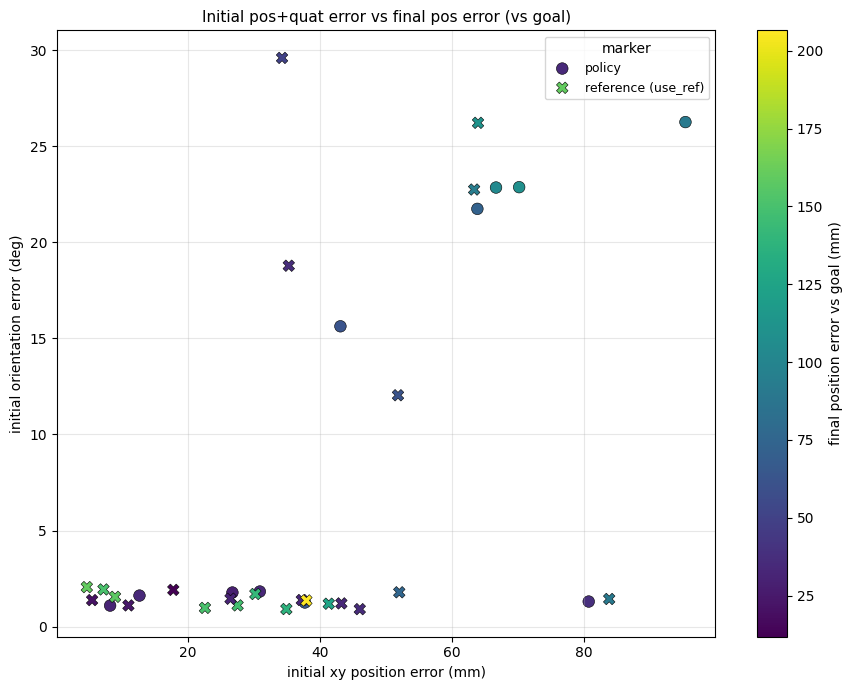

In [201]:
# init pos err (x) + init quat err (y) -> final error. 2d (colour) is the most readable.
plot_initpq_vs_final(df, z="pos")                          # 2d heat: final pos error
# plot_initpq_vs_final(df, z="quat")                       # 2d heat: final quat error
# plot_initpq_vs_final(df, z="quat", view="3d")            # 3d w/ dotted stems to floor
# plot_initpq_vs_final(df, z="pos", view="3d", annotate=True)


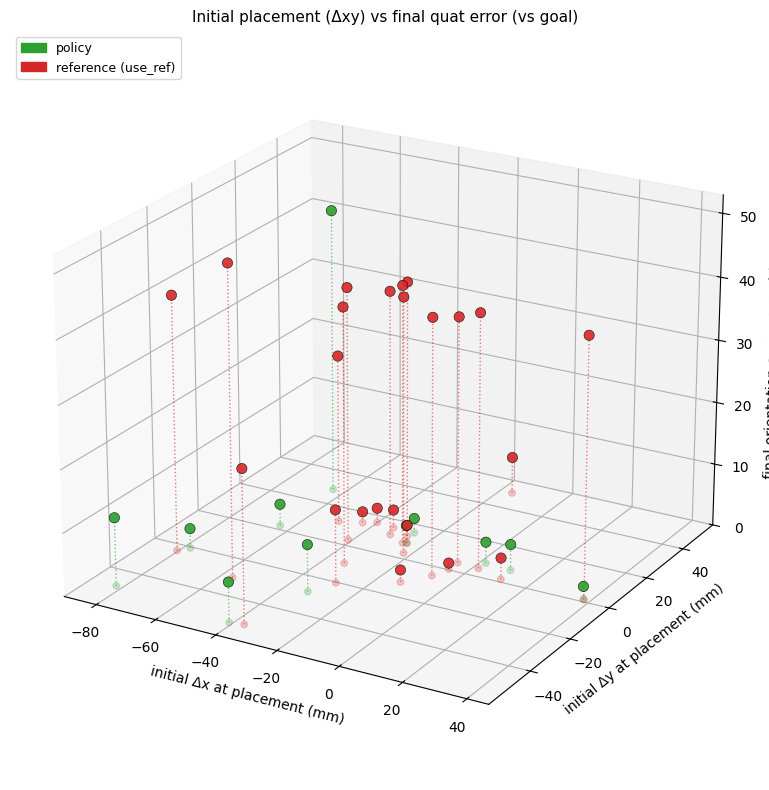

In [211]:
# Initial placement Δxy (horizontal) vs final error (vertical), one point per rollout.
# plot_initxy_vs_final(df, z="pos")                       # final xy position error (mm)
plot_initxy_vs_final(df, z="quat")                    # final orientation error (deg)
# plot_initxy_vs_final(df, z="quat", final="phase", annotate=True)
# plot_initxy_vs_final(df, z="pos", elev=30, azim=-120) # rotate the 3D view


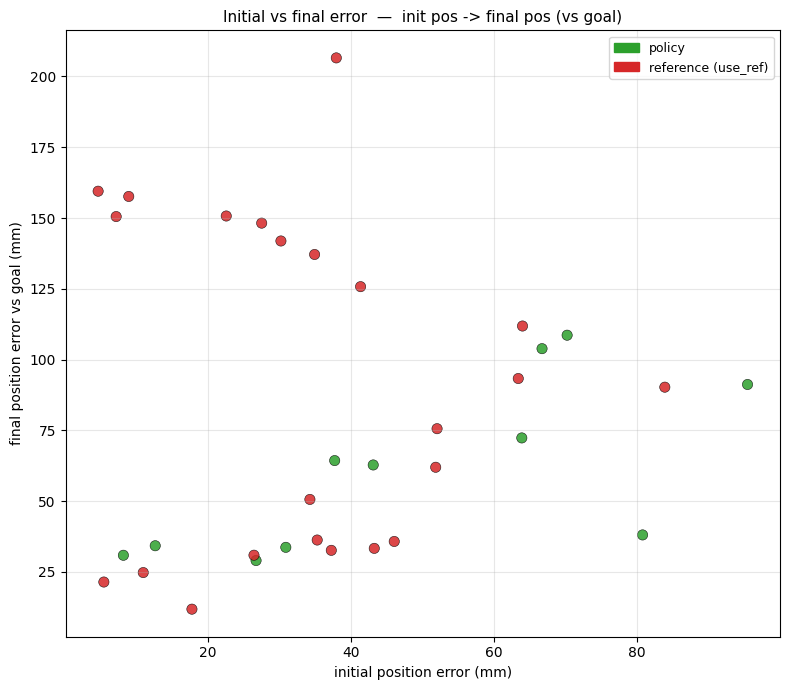

In [210]:
plot_init_vs_final(df, x="pos", y="pos")                                 # init pos -> final pos (vs goal)
# plot_init_vs_final(df, x="quat", y="quat")           # quat -> quat
# plot_init_vs_final(df, x="pos",  y="quat")           # initial placement vs final orientation
# plot_init_vs_final(df, x="quat", y="pos")            # initial tilt vs final position
# plot_init_vs_final(df, y="quat", final="phase", annotate=True)


In [204]:
df.keys()

Index(['npz', 'use_ref', 'gain', 'lookahead', 'init_phase', 'init_xy_err_m',
       'init_pos_delta_m', 'init_ori_err_deg', 'final_phase', 'completed',
       'xy_err_m', 'pos_delta_m', 'ori_err_deg', 'xy_err_at_phase_m',
       'ori_err_at_phase_deg'],
      dtype='str')

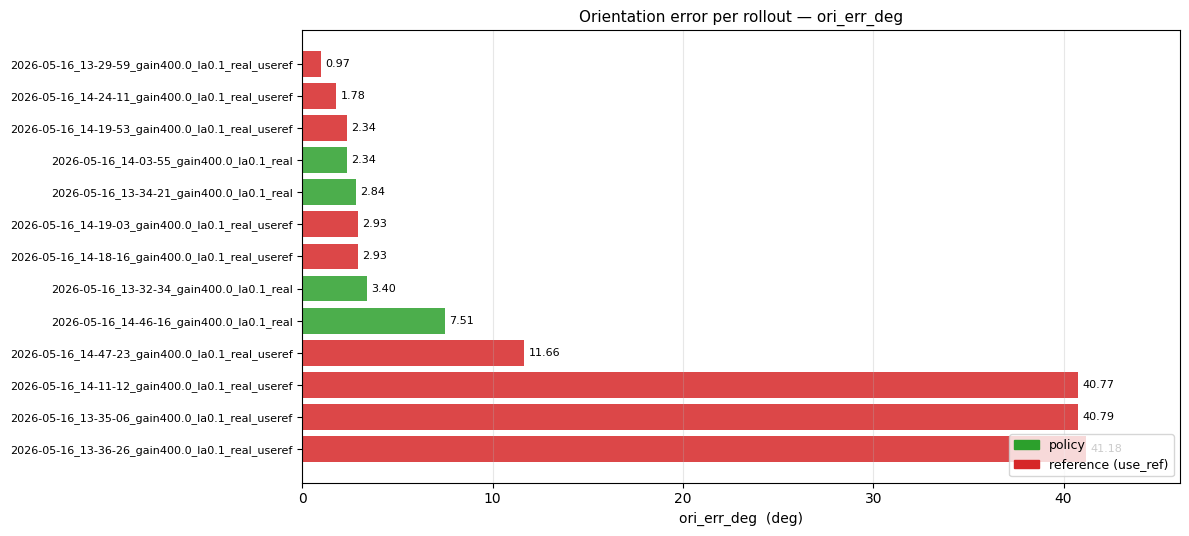

In [ ]:
plot_error(df)